<a href="https://colab.research.google.com/github/uwol1116/GAI-Class/blob/main/Programming%20Assignment%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load data
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

num_epochs = 10


In [9]:
# Problem 1: Logistic Regression
model1 = nn.Linear(784, 10)
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.SGD(model1.parameters(), lr=0.01) # SGD

loss_history1 = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.view(-1, 784)
        outputs = model1(images)
        loss = criterion(outputs, labels)

        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history1.append(avg_loss)
    print(f'  - Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')


Test accuracy: 90.96%


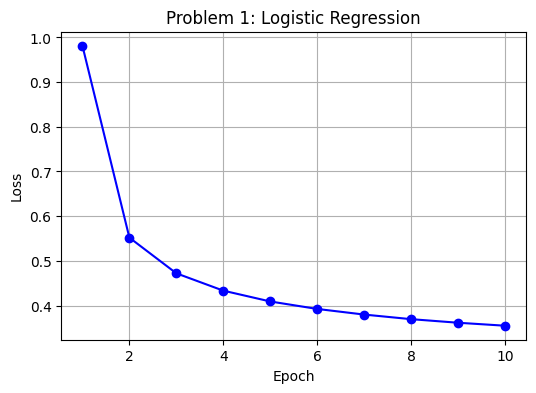

In [10]:
model1.eval()
correct1, total1 = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 784)
        _, predicted = torch.max(model1(images).data, 1)
        total1 += labels.size(0)
        correct1 += (predicted == labels).sum().item()
acc1 = 100 * correct1 / total1

print(f"\nTest accuracy: {acc1:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), loss_history1, marker='o', color='blue')
plt.title('Problem 1: Logistic Regression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [11]:
# 2. Problem 2 — Neural Network (Classification)
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model2 = Net()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001) # Adam

loss_history2 = []
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        outputs = model2(images)
        loss = criterion(outputs, labels)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history2.append(avg_loss)
    print(f'  - Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

  - Epoch [1/10], Loss: 0.3469
  - Epoch [2/10], Loss: 0.1599
  - Epoch [3/10], Loss: 0.1114
  - Epoch [4/10], Loss: 0.0840
  - Epoch [5/10], Loss: 0.0669
  - Epoch [6/10], Loss: 0.0539
  - Epoch [7/10], Loss: 0.0432
  - Epoch [8/10], Loss: 0.0360
  - Epoch [9/10], Loss: 0.0295
  - Epoch [10/10], Loss: 0.0242



Test accuracy: 97.75%


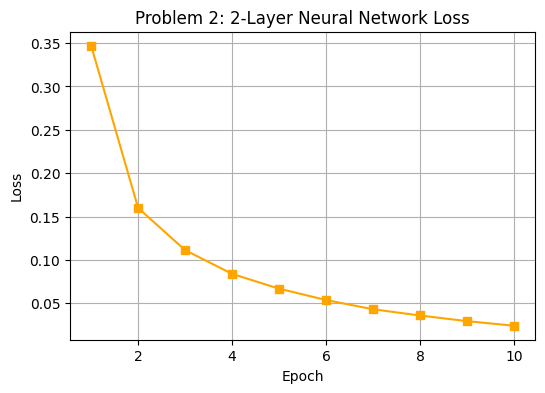

In [12]:
model2.eval()
correct2, total2 = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        _, predicted = torch.max(model2(images).data, 1)
        total2 += labels.size(0)
        correct2 += (predicted == labels).sum().item()
acc2 = 100 * correct2 / total2

print(f"\nTest accuracy: {acc2:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), loss_history2, marker='s', color='orange')
plt.title('Problem 2: Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

1. Logistic Regression (SGD):   90.96%
2. 2-Layer Neural Net (Adam):   97.75%
Accuracy difference : 6.79%p 



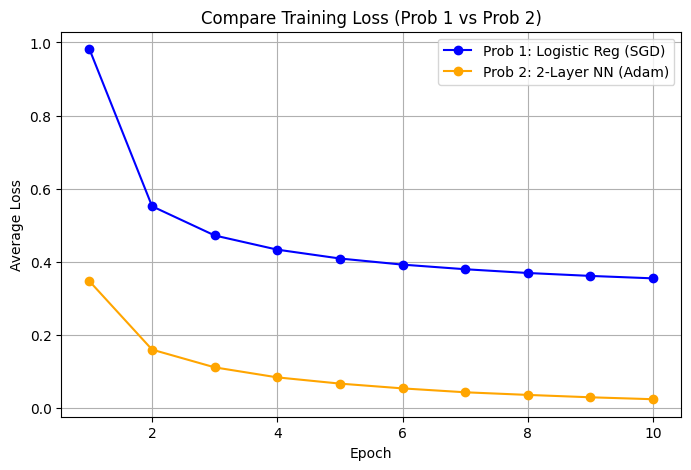

In [14]:
# Compare performance with Problem 1 and 2

print(f"1. Logistic Regression (SGD):   {acc1:.2f}%")
print(f"2. 2-Layer Neural Net (Adam):   {acc2:.2f}%")
print(f"Accuracy difference : {acc2 - acc1:.2f}%p \n")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history1, label='Prob 1: Logistic Reg (SGD)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), loss_history2, label='Prob 2: 2-Layer NN (Adam)', marker='o', color='orange')

plt.title('Compare Training Loss (Prob 1 vs Prob 2)')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.grid(True)
plt.show()